<a href="https://colab.research.google.com/github/emir-utku-ozgen/atellite-Building-Damage-Detection-YOLOv8/blob/main/deprem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

!pip install ultralytics roboflow

from roboflow import Roboflow
import os

from google.colab import userdata

api_key = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=api_key)
project = rf.workspace("emirs-workspace-nnmkn").project("building-damage-detection-zwxco-grhvr")
version = project.version(1)
dataset = version.download("yolov8")

print("\n🚀 VERİ SETİ GÜVENLİ ŞEKİLDE İNDİ KANKA!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.5 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...

🚀 KÜTÜPHANELER KURULDU VE VERİ SETİ İNDİ KANKA!


In [4]:
from ultralytics import YOLO
import os


model = YOLO("yolov8m.pt")
yaml_yolu = os.path.join(dataset.location, "data.yaml")

print("🚀 v3 (Ultra): YOLOv8-Medium ve Gelişmiş Parametrelerle Eğitim Başlıyor...")
results = model.train(
    data=yaml_yolu,
    optimizer='AdamW',
    epochs=25,
    imgsz=640,
    device="0",


    cos_lr=True,
    augment=True,
    box=7.5,
    cls=1.5
)

print("\n🎉 MUAZZAM BAŞARI EMİR! Hasar Tespit Modelin runs/detect/train/weights/best.pt konumunda hazır!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 v3 (Ultra): YOLOv8-Medium ve Gelişmiş Parametrelerle Eğitim Başlıyor...
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Building-Damage-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=to


🔍 Model test ediliyor ve uydudan hasarlı binalar tahmin ediliyor cano...

0: 640x640 7 0s, 8 1s, 33.5ms
1: 640x640 6 1s, 1 3, 1 undefined, 33.5ms
2: 640x640 2 0s, 3 3s, 33.5ms
Speed: 3.2ms preprocess, 33.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

Tahmin Edilen Uydu Resmi: image2.jpg


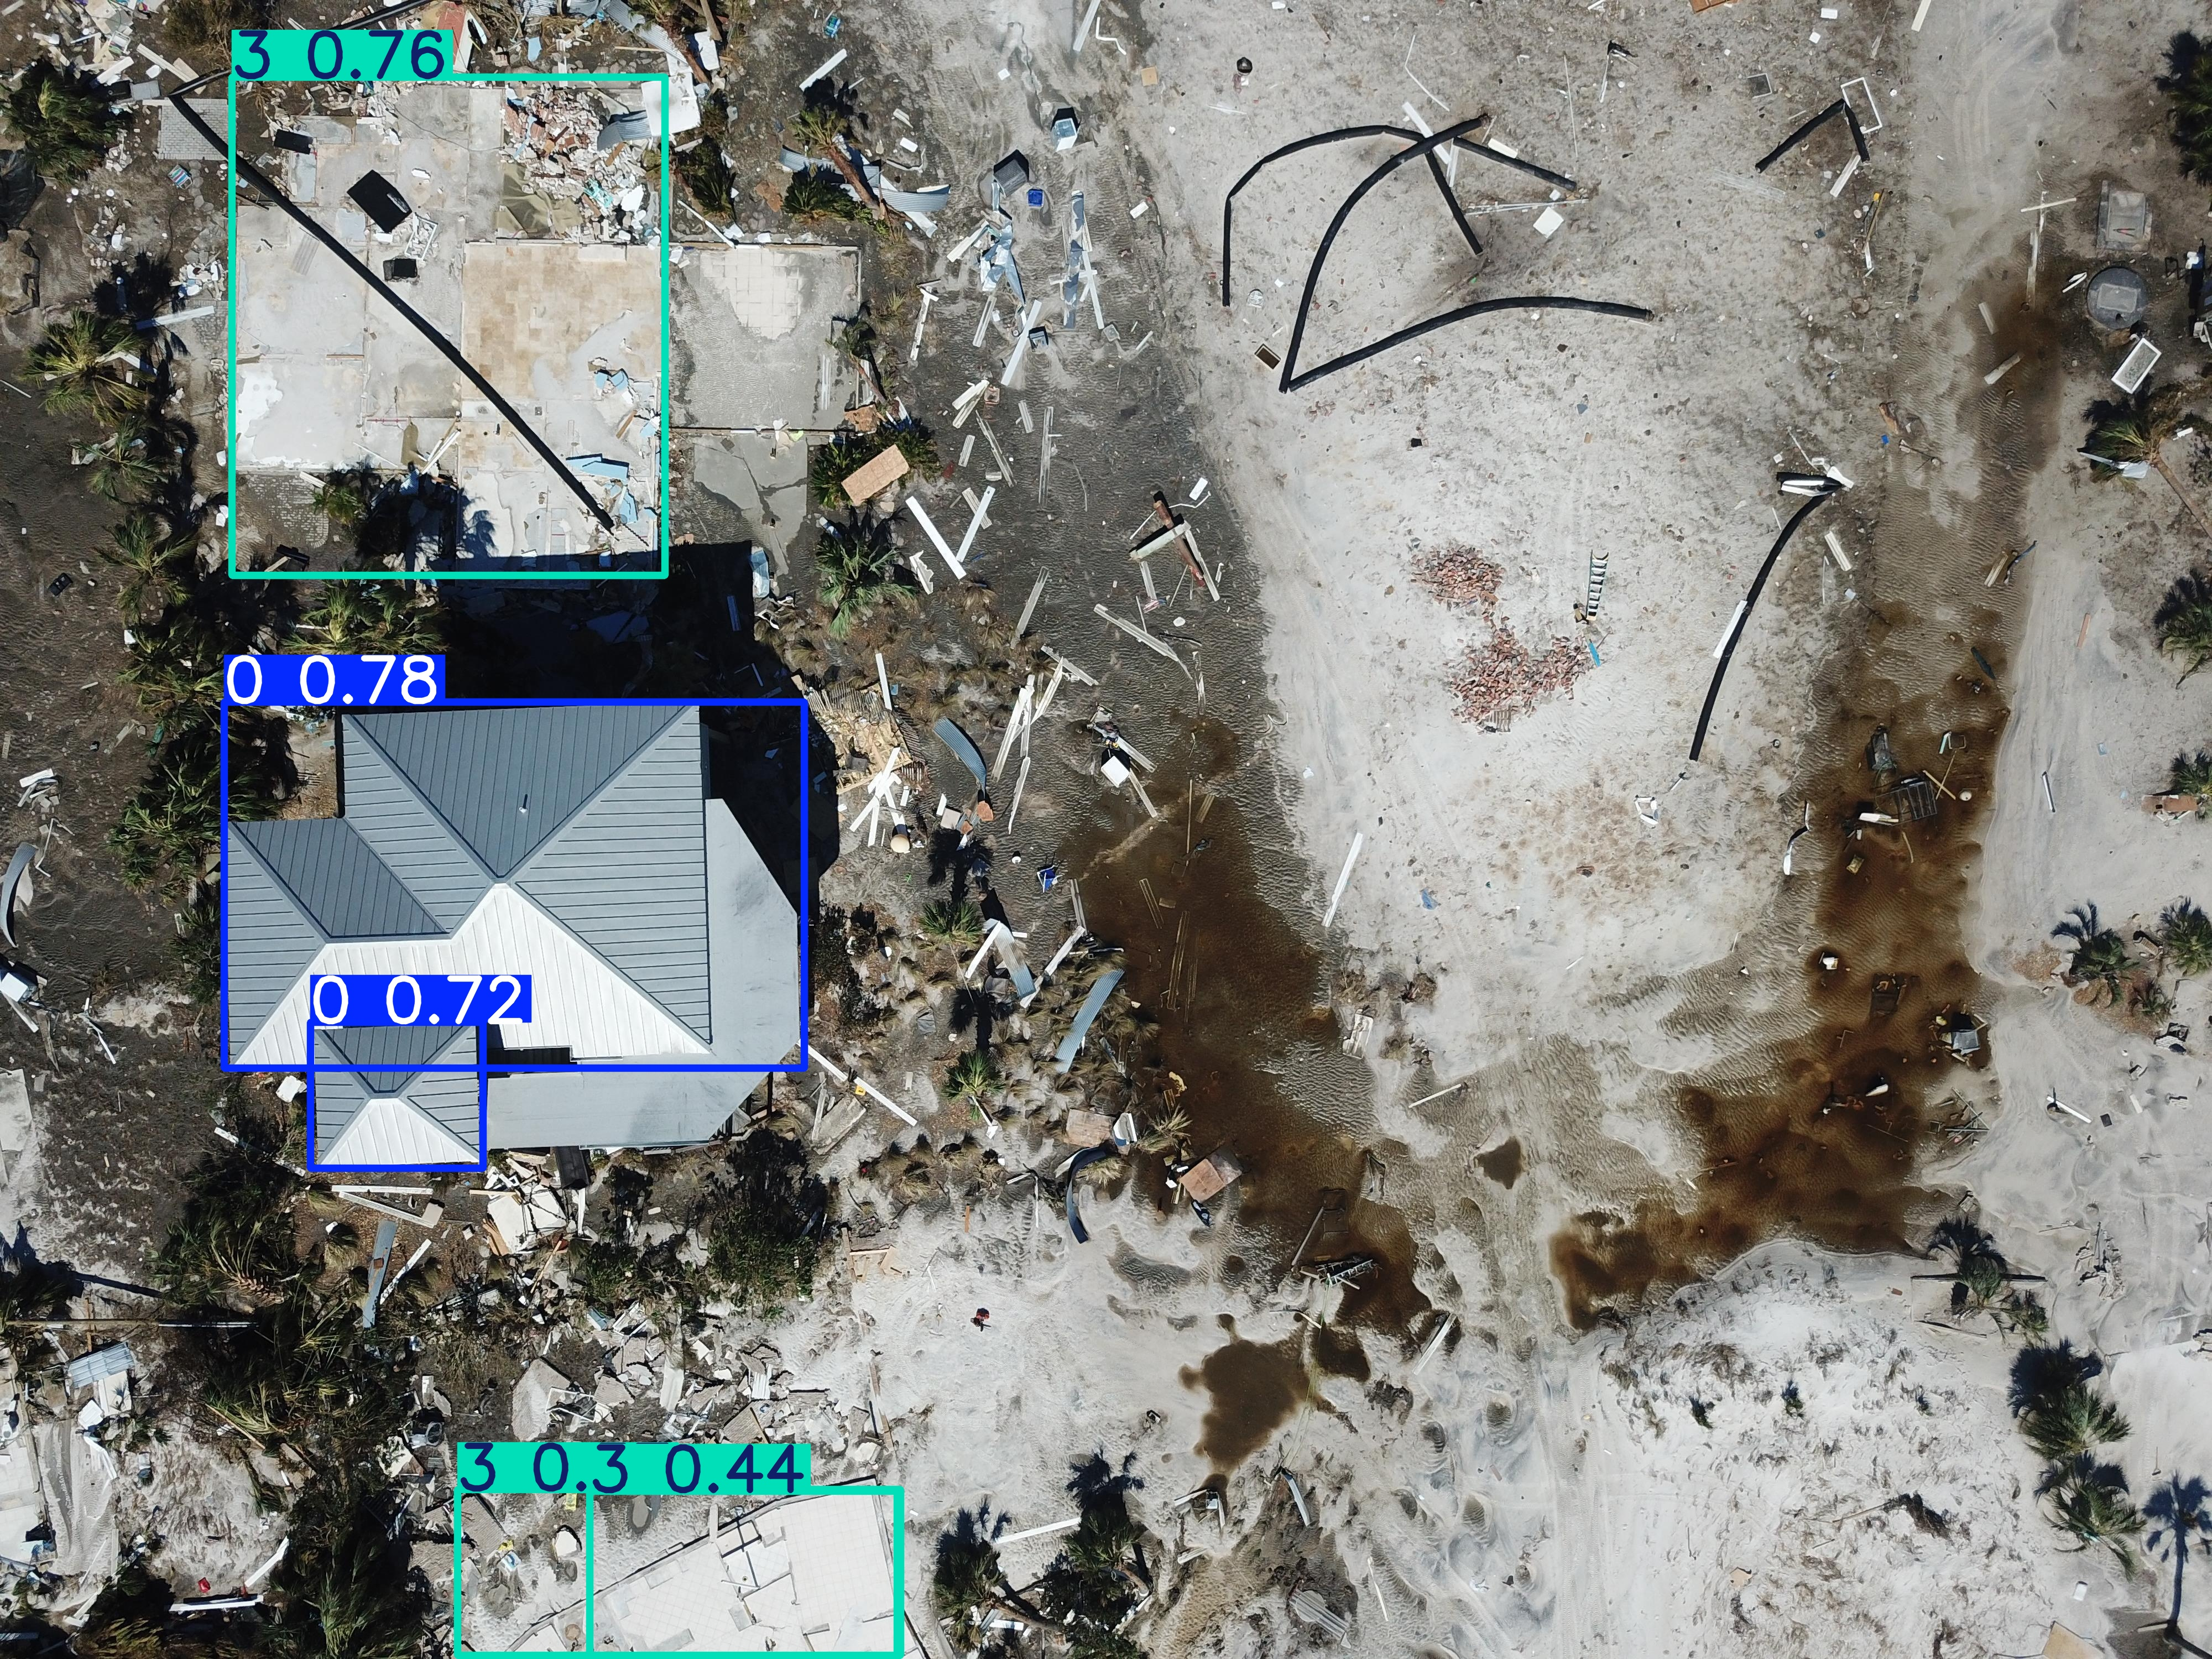


Tahmin Edilen Uydu Resmi: image1.jpg


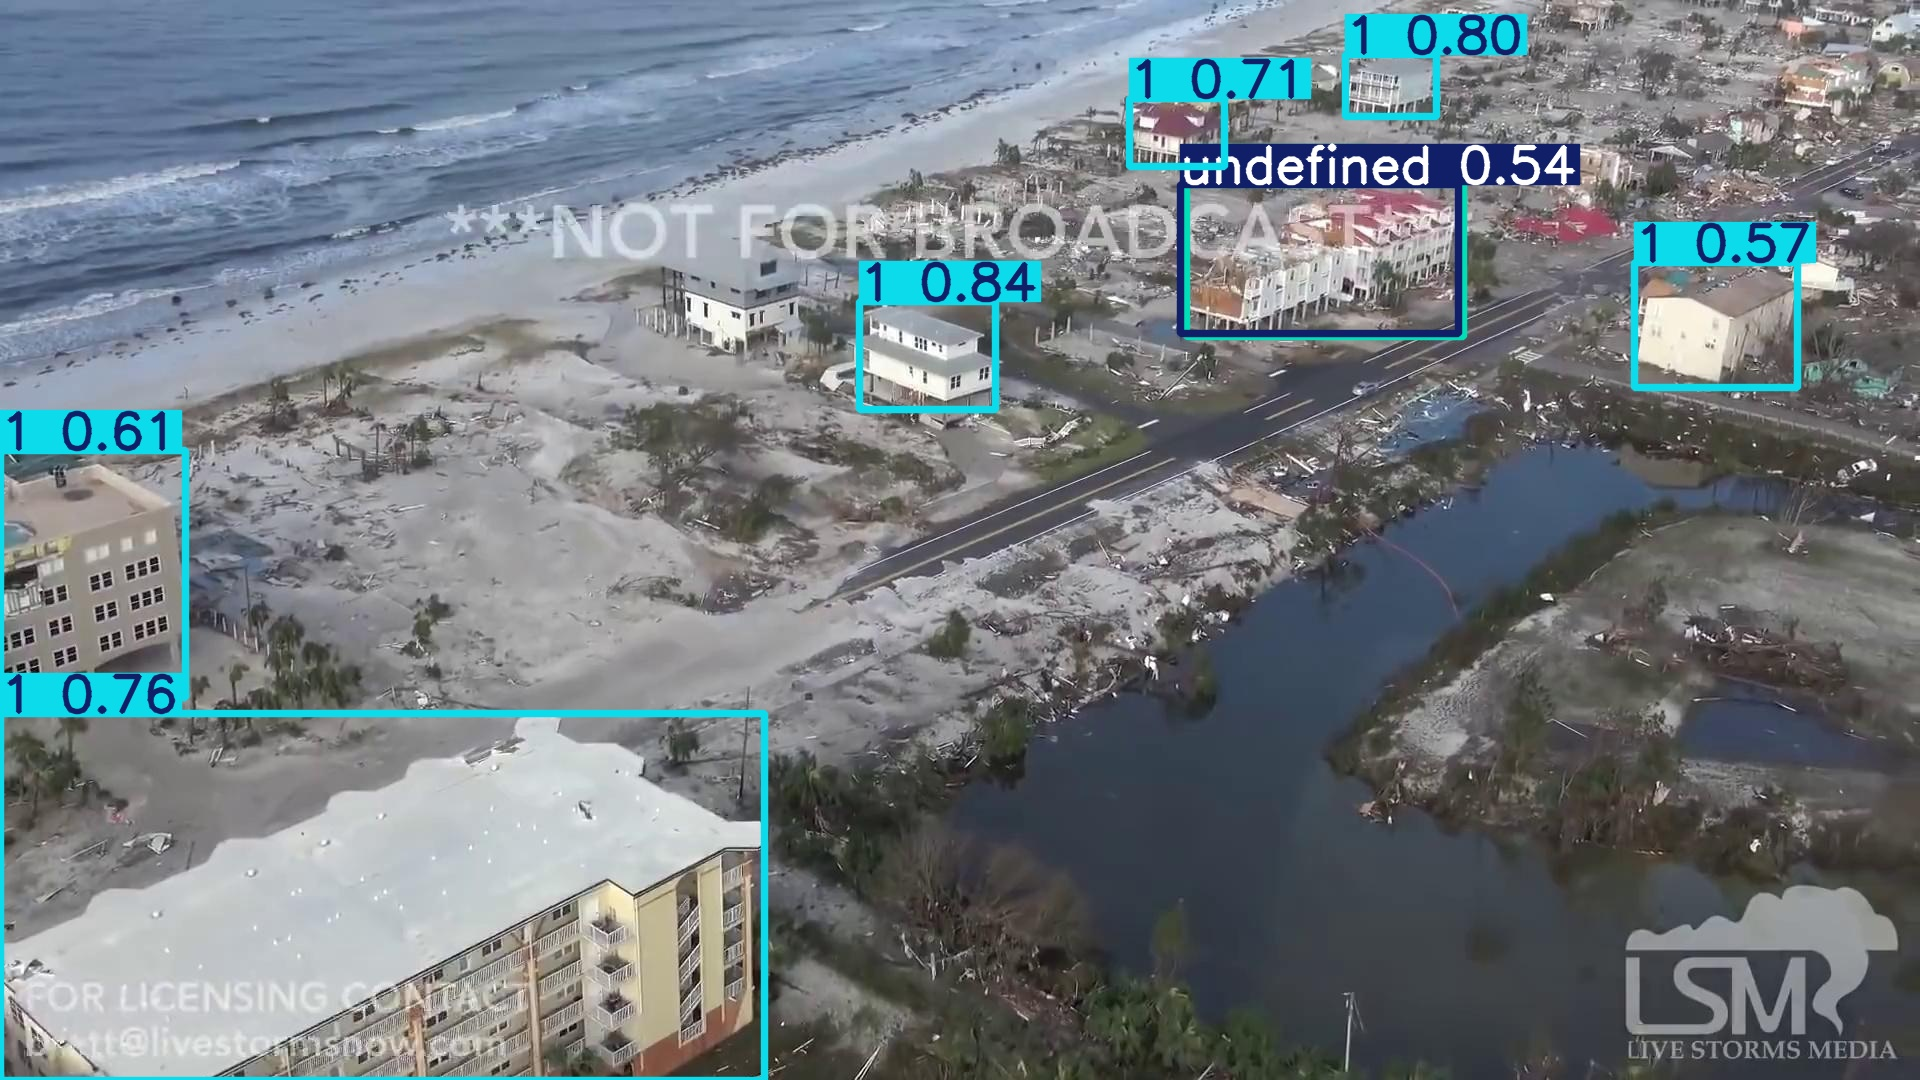


Tahmin Edilen Uydu Resmi: image0.jpg


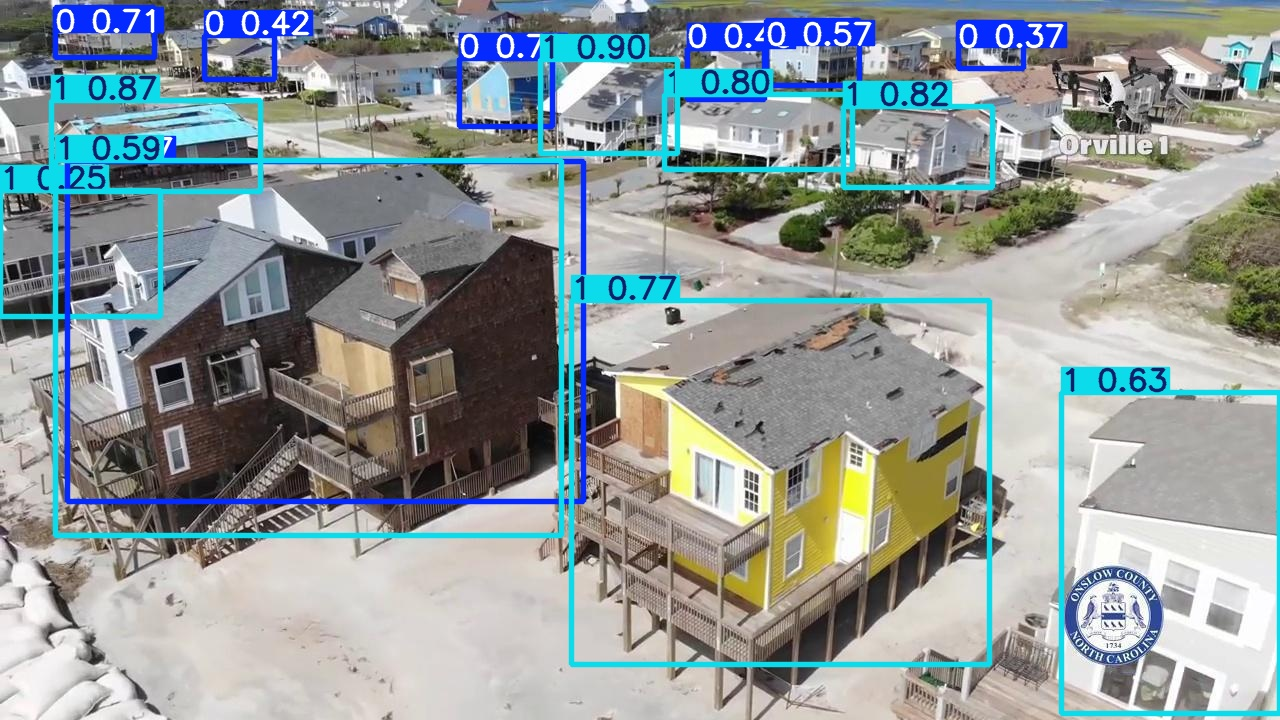


🎉 TEST TAMAMLANDI EMİR! Resimler yukarıda basıldı cano.


In [5]:

from ultralytics import YOLO
import os
import glob
from IPython.display import Image, display


model_yolu = "runs/detect/train/weights/best.pt"
model = YOLO(model_yolu)


test_resimleri = glob.glob(os.path.join(dataset.location, "test/images/*.jpg"))[:3]

print("\n🔍 Model test ediliyor ve uydudan hasarlı binalar tahmin ediliyor cano...")

results = model.predict(source=test_resimleri, conf=0.25, save=True)


predict_klasoru = sorted(glob.glob("runs/detect/predict*"))[-1]
for resim_yolu in glob.glob(os.path.join(predict_klasoru, "*.jpg")):
    print(f"\nTahmin Edilen Uydu Resmi: {os.path.basename(resim_yolu)}")
    display(Image(filename=resim_yolu))

print("\n🎉 TEST TAMAMLANDI EMİR! Resimler yukarıda basıldı cano.")